# 06. Tensors and multidimensional remote-sensing data

**Instructor:** Efraín Padilla — DLR IMF-ASP

**Suggested duration:** approximately 25 minutes.

This section introduces the tensor viewpoint used in Kolda and Bader (2009). We move from a single sample represented by a vector to matrices and third-order tensors that preserve spatial and spectral organization.

The main reference is [Kolda & Bader, Tensor Decompositions and Applications](https://doi.org/10.1137/07070111X). The notation below follows their distinction between order, modes, entries, fibers, and slices.

## Learning goals

By the end of this section, you should be able to:

- describe a single pixel spectrum as a vector and a band image as a matrix;
- identify the spatial and spectral modes of a third-order image tensor;
- use Kolda and Bader's entry, fiber, and slice notation; and
- explain why preserving the image cube can help a model exploit spatial and spectral correlations.

## 6.1 From feature vectors to spatial slices

So far, a sample has usually been written as a vector with *n* features. For one pixel in a multispectral image, that is a natural description: the pixel has one value per spectral band.

Kolda and Bader use the following notation:

| Object | Order | Example notation | Meaning here |
| --- | ---: | --- | --- |
| scalar | 0 | *a* | one measured value |
| vector | 1 | **a** with entry *aᵢ* | one pixel spectrum |
| matrix | 2 | **A** with entry *aᵢⱼ* | one band image |
| tensor | 3 or more | 𝓧 with entry *xᵢⱼₖ* | the complete image cube |

For a single image, let the row index be *i*, the column index be *j*, and the band index be *k*. A pixel spectrum is the mode-3 fiber 𝓧ᵢⱼ:, while a band image is the frontal slice 𝓧::k. The colon means that the corresponding index is allowed to vary.

This is more than a change of notation. A vector tells us which values belong to one pixel. A matrix tells us where values occur across the image. The tensor keeps both relationships at the same time.

In [13]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from torchgeo.datasets import EuroSAT100

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "font.size": 11,
})

### A different EuroSAT100 image

We use the same prepared dataset as Section 05, but deliberately select a forest image rather than the river example used there. The dataset stores each sample as (bands, height, width). For the tensor notation in this section, we move the band axis to the end and write the image as 𝓧 with shape (height, width, bands).

In [14]:
dataset_root = Path("data") / "eurosat100"
bands = EuroSAT100.all_band_names
eurosat_train = EuroSAT100(
    root=dataset_root,
    split="train",
    bands=bands,
    download=True,
    checksum=True,
)
selected_sample = eurosat_train[1]

if selected_sample is None:
    raise RuntimeError(f"No {target_class!r} sample was found in the training split.")

# TorchGeo uses (band, row, column); use (row, column, band) below.
image_bhw = selected_sample["image"].detach().cpu().numpy()
X = np.moveaxis(image_bhw, 0, -1)
band_names = tuple(eurosat_train.bands)
label = int(selected_sample["label"])
class_name = eurosat_train.classes[label]

print(f"Selected image index: {selected_index}")
print(f"Class: {class_name}")
print(f"Tensor shape: X in R^({X.shape[0]} x {X.shape[1]} x {X.shape[2]})")
print(f"Modes: rows I={X.shape[0]}, columns J={X.shape[1]}, bands K={X.shape[2]}")
print(f"Band order: {band_names}")

Selected image index: 6
Class: AnnualCrop
Tensor shape: X in R^(64 x 64 x 13)
Modes: rows I=64, columns J=64, bands K=13
Band order: ('B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B09', 'B10', 'B11', 'B12', 'B8A')


The array now follows the third-order convention: 𝓧 belongs to R with dimensions I by J by K, and xᵢⱼₖ is the value at row *i*, column *j*, and band *k*.

Here, *I* and *J* describe the spatial grid and *K* is the number of spectral bands. The entry *xᵢⱼₖ* is one measurement at one row, one column, and one band.

In [15]:
I, J, K = X.shape
row, column = I // 2, J // 2
band_index = band_names.index("B08")

pixel_spectrum = X[row, column, :]
band_slice = X[:, :, band_index]

assert pixel_spectrum.shape == (K,)
assert band_slice.shape == (I, J)

print(f"Entry x_{{{row},{column},{band_index}}}: {X[row, column, band_index]}")
print(f"Mode-3 fiber X_{{{row},{column},:}} shape: {pixel_spectrum.shape}")
print(f"Frontal slice X_{{:,:,{band_index}}} shape: {band_slice.shape}")

Entry x_{32,32,7}: 2627.0
Mode-3 fiber X_{32,32,:} shape: (13,)
Frontal slice X_{:,:,7} shape: (64, 64)


### Seeing the matrix slices

Every band gives one matrix 𝓧::k. The matrices have the same spatial coordinates, but each one measures a different part of the electromagnetic spectrum. The false-color RGB image below is only a display convention; the model still has access to all 13 matrices.

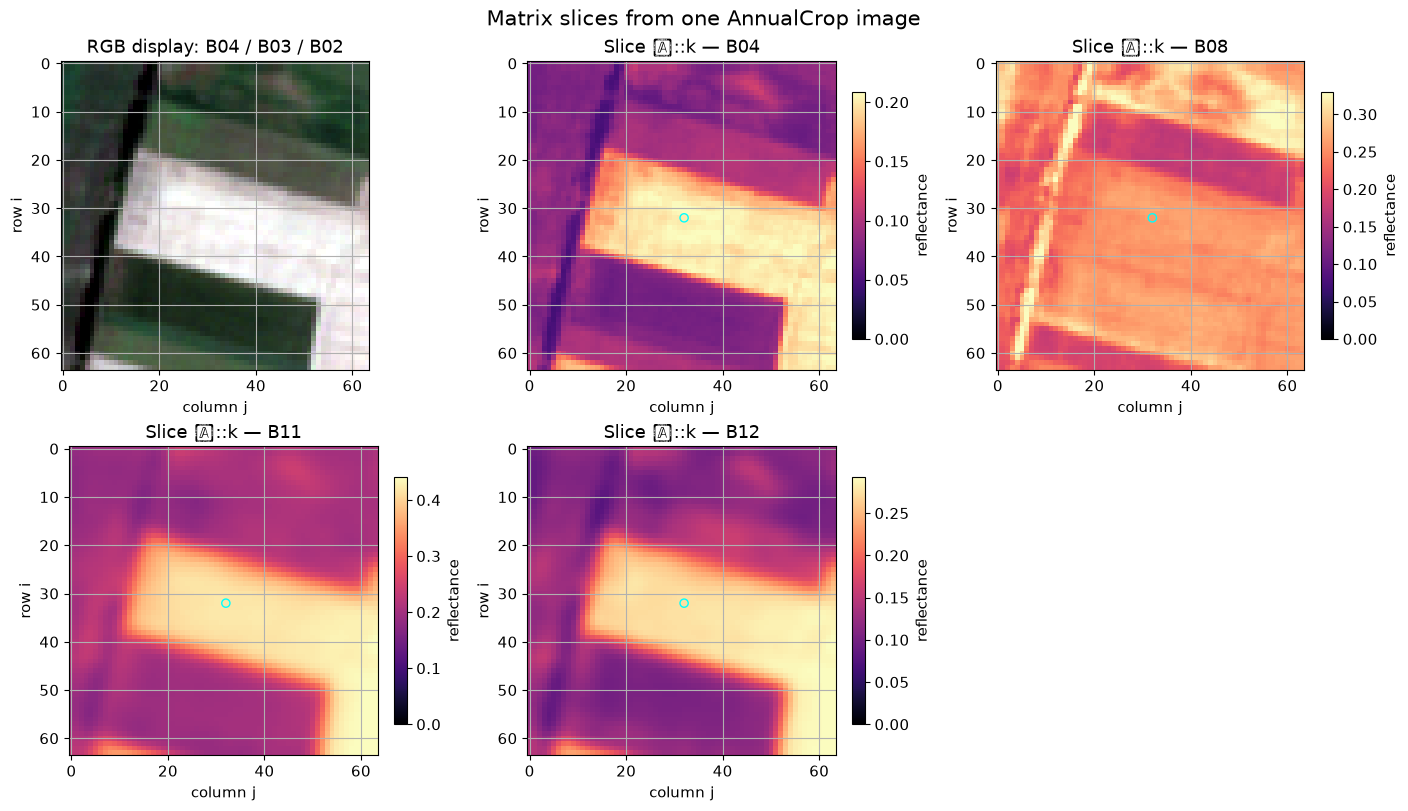

In [16]:
reflectance = np.clip(X.astype(float) / 10000.0, 0, 1)

def percentile_stretch(image, low=2, high=98):
    lower, upper = np.percentile(image, (low, high), axis=(0, 1), keepdims=True)
    return np.clip((image - lower) / np.maximum(upper - lower, 1e-6), 0, 1)

rgb_indices = [band_names.index(band) for band in ("B04", "B03", "B02")]
rgb = percentile_stretch(reflectance[:, :, rgb_indices])
display_bands = ("B04", "B08", "B11", "B12")

fig, axes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)
axes = axes.ravel()
axes[0].imshow(rgb)
axes[0].set_title("RGB display: B04 / B03 / B02")
axes[0].set_xlabel("column j")
axes[0].set_ylabel("row i")
for ax, band in zip(axes[1:], display_bands):
    band_matrix = reflectance[:, :, band_names.index(band)]
    image = ax.imshow(band_matrix, cmap="magma", vmin=0, vmax=np.percentile(band_matrix, 99))
    ax.scatter(column, row, s=35, facecolors="none", edgecolors="cyan")
    ax.set_title(f"Slice 𝓧::k — {band}")
    ax.set_xlabel("column j")
    ax.set_ylabel("row i")
    fig.colorbar(image, ax=ax, shrink=0.8, label="reflectance")
axes[-1].axis("off")
fig.suptitle(f"Matrix slices from one {class_name} image", fontsize=15)
plt.show()

## 6.2 Third-order tensors: the image cube

Stacking the band matrices gives the natural data object for a multispectral patch: 𝓧 is a third-order array with dimensions I by J by K, whose frontal slices are 𝓧::1, 𝓧::2, and so on through 𝓧::K.

This is a third-order tensor: two modes describe space and one mode describes wavelength. The mode-1 and mode-2 fibers run through the image in spatial directions. The mode-3 fiber 𝓧ᵢⱼ: is the spectrum at one pixel.

A vector-only model can still be useful. It treats each pixel as one sample and 𝓧ᵢⱼ: as its feature vector. But if we flatten the whole patch into unrelated rows, we hide which pixels are neighbors and which values belong to the same band image. Convolutional and tensor-based models can preserve those relationships and learn spatial, spectral, or joint spatial-spectral patterns.

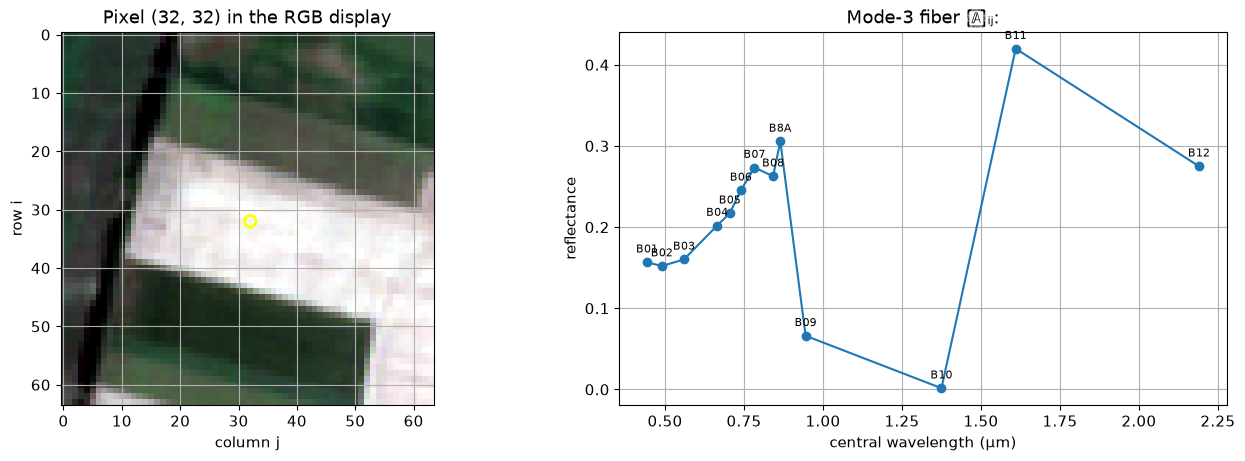

In [17]:
central_wavelengths = {
    "B01": 0.443, "B02": 0.490, "B03": 0.560, "B04": 0.665,
    "B05": 0.705, "B06": 0.740, "B07": 0.783, "B08": 0.842,
    "B8A": 0.865, "B09": 0.945, "B10": 1.375, "B11": 1.610,
    "B12": 2.190,
}
spectral_order = sorted(band_names, key=central_wavelengths.__getitem__)
spectral_indices = [band_names.index(band) for band in spectral_order]
wavelengths = [central_wavelengths[band] for band in spectral_order]
spectrum = reflectance[row, column, spectral_indices]

fig, (ax_image, ax_spectrum) = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
ax_image.imshow(rgb)
ax_image.scatter(column, row, s=70, facecolors="none", edgecolors="yellow", linewidths=2)
ax_image.set_title(f"Pixel ({row}, {column}) in the RGB display")
ax_image.set_xlabel("column j")
ax_image.set_ylabel("row i")
ax_spectrum.plot(wavelengths, spectrum, marker="o")
for wavelength, value, band in zip(wavelengths, spectrum, spectral_order):
    ax_spectrum.annotate(band, (wavelength, value), xytext=(0, 7), textcoords="offset points", ha="center", fontsize=8)
ax_spectrum.set_title("Mode-3 fiber 𝓧ᵢⱼ:")
ax_spectrum.set_xlabel("central wavelength (µm)")
ax_spectrum.set_ylabel("reflectance")
plt.show()

### A 3D view of the cube

The next plot places one band matrix at each value of the spectral mode *k*. Each colored plane is a frontal slice 𝓧::k. The planes are downsampled only for display, while the tensor used in the earlier calculations remains unchanged. Rotate the figure in an interactive notebook to inspect how the same spatial structure changes from band to band.

/root/miniforge3/envs/neural-networks-workshop/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 120039 (\N{MATHEMATICAL BOLD SCRIPT CAPITAL X}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


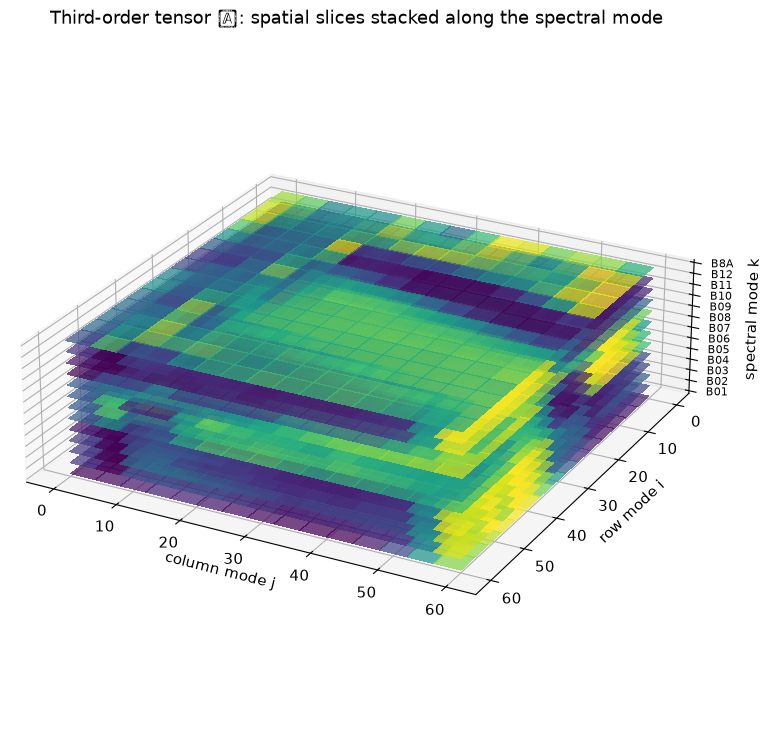

In [18]:
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 — registers the 3D projection

def plot_tensor_cube(tensor, names, stride=4):
    rows, columns, bands_count = tensor.shape
    row_indices = np.arange(0, rows, stride)
    column_indices = np.arange(0, columns, stride)
    band_values = np.clip(tensor[np.ix_(row_indices, column_indices, np.arange(bands_count))] / 10000.0, 0, 1)
    row_grid, column_grid = np.meshgrid(row_indices, column_indices, indexing="ij")

    fig = plt.figure(figsize=(11, 9))
    ax = fig.add_subplot(111, projection="3d")
    for band_index in range(bands_count):
        band_image = band_values[:, :, band_index]
        lower, upper = np.percentile(band_image, (2, 98))
        band_display = np.clip((band_image - lower) / max(upper - lower, 1e-6), 0, 1)
        height = np.full_like(row_grid, band_index, dtype=float)
        ax.plot_surface(
            column_grid,
            row_grid,
            height,
            facecolors=cm.viridis(band_display),
            linewidth=0,
            antialiased=False,
            shade=False,
            alpha=0.72,
        )

    ax.set_title("Third-order tensor 𝓧: spatial slices stacked along the spectral mode")
    ax.set_xlabel("column mode j")
    ax.set_ylabel("row mode i")
    ax.set_zlabel("spectral mode k")
    ax.set_zticks(np.arange(bands_count))
    ax.set_zticklabels(names, fontsize=8)
    ax.invert_yaxis()
    ax.set_box_aspect((columns, rows, bands_count * 1.5))
    ax.view_init(elev=25, azim=-62)
    plt.show()

plot_tensor_cube(image_bhw.transpose(1, 2, 0), band_names)

## Take-away

The same remote-sensing patch supports several valid views:

- 𝓧ᵢⱼ: is one spectral feature vector for a pixel;
- 𝓧::k is one spatial matrix for a band; and
- 𝓧 with dimensions I by J by K is the complete spatial-spectral cube.

None of these views is universally best. The useful choice depends on the task and on which correlations the model should learn. The important point is to make the choice explicit instead of silently flattening away the structure of the data.

## Reference

Kolda, T. G., & Bader, B. W. (2009). Tensor decompositions and applications. *SIAM Review, 51*(3), 455–500. [https://doi.org/10.1137/07070111X](https://doi.org/10.1137/07070111X)

The notation used here is adapted from Section 2 of the paper, especially its definitions of tensor order, modes, entries, fibers, and slices.